# 🧠 01 — Entrenamiento Expertos 2D (Tasks 1.3, 1.4, 1.5)

Entrena los 3 expertos 2D de forma secuencial (**Método B — Por Partes**):
- **Experto 1** → NIH ChestX-ray14 (ConvNeXt-Tiny) — BCEWithLogitsLoss
- **Experto 2** → ISIC 2019 (EfficientNet-B3) — CrossEntropyLoss ponderada  
- **Experto 3** → Osteoarthritis (ResNet-34) — CrossEntropyLoss

Cada experto se guarda como `.pth` en `/workspace/checkpoints/` (Task 1.6).

## 0. Configuración 

In [1]:
pip install --upgrade pip --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install tqdm scikit-learn scipy numpy timm opencv-python pandas SimpleITK matplotlib kornia torch --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 --quiet

Note: you may need to restart the kernel to use updated packages.


In [23]:
import sys, torch
sys.path.insert(0, '/workspace/moe_medical_vision/src')

from pathlib import Path

# ─── PATHS 
DATASET_PATHS = {
    'nih_chestxray':  '/workspace/moe_medical_vision/data/raw/nih',
    'isic2019':       '/workspace/moe_medical_vision/data/raw/isic',
    'osteoarthritis': '/workspace/moe_medical_vision/data/raw/osteoporosis/KLGrade/KLGrade',
}
CHECKPOINT_DIR = Path('/workspace/moe_medical_vision/checkpoints')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# ─── HIPERPARÁMETROS ───
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS_2D   = 20
LR          = 1e-3
BATCH_SIZE  = 512
NUM_WORKERS = 8
USE_FP16    = True    # Mixed Precision obligatorio
ACCUM_STEPS = 1       # Gradient Accumulation → batch efectivo = 128
SEED        = 42

print(f'Device: {DEVICE}')
print(f'Checkpoints → {CHECKPOINT_DIR}')


import torch, random, numpy as np
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print(torch.cuda.get_device_name(0))

Device: cuda
Checkpoints → /workspace/moe_medical_vision/checkpoints
NVIDIA GeForce RTX 4090


## 1. Loop de entrenamiento genérico

In [24]:
import torch
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler
from tqdm.notebook import tqdm
from sklearn.metrics import f1_score
import numpy as np


def train_expert(
    model: nn.Module,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    expert_name: str,
    epochs: int,
    is_multilabel: bool = False,
    accum_steps: int = 4,
):
    """
    Loop de entrenamiento genérico con:
    - Mixed Precision (FP16)
    - Gradient Accumulation
    - Early stopping (patience=5)
    - Guardado del mejor checkpoint
    """
    model = model.to(DEVICE)
    scaler = GradScaler(enabled=USE_FP16)
    
    best_f1    = 0.0
    patience   = 5
    no_improve = 0
    history    = {'train_loss': [], 'val_f1': []}

    for epoch in range(1, epochs + 1):
        # ── TRAIN ──
        model.train()
        total_loss = 0.0
        optimizer.zero_grad()

        pbar = tqdm(train_loader, desc=f'[{expert_name}] Epoch {epoch}/{epochs}', leave=False)
        for step, batch in enumerate(pbar):
            images = batch['image'].to(DEVICE)
            labels = batch['label'].to(DEVICE)

            with autocast(enabled=USE_FP16):
                logits = model(images)
                loss   = criterion(logits, labels) / accum_steps

            scaler.scale(loss).backward()

            if (step + 1) % accum_steps == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            total_loss += loss.item() * accum_steps
            pbar.set_postfix(loss=f'{loss.item() * accum_steps:.4f}')

        avg_loss = total_loss / len(train_loader)

        # ── VALIDACIÓN ──
        model.eval()
        all_preds, all_labels = [], []

        with torch.no_grad():
            for batch in val_loader:
                images = batch['image'].to(DEVICE)
                labels = batch['label']
                with autocast(enabled=USE_FP16):
                    logits = model(images)

                if is_multilabel:
                    preds = (torch.sigmoid(logits.cpu()) > 0.5).int()
                else:
                    preds = logits.cpu().argmax(dim=1)

                all_preds.append(preds.numpy())
                all_labels.append(labels.numpy())

        all_preds  = np.concatenate(all_preds)
        all_labels = np.concatenate(all_labels)

        avg_type = 'macro' if not is_multilabel else 'samples'
        f1 = f1_score(all_labels, all_preds, average=avg_type, zero_division=0)

        history['train_loss'].append(avg_loss)
        history['val_f1'].append(f1)

        if scheduler:
            scheduler.step(f1)

        print(f'  Epoch {epoch:02d}/{epochs} | Loss: {avg_loss:.4f} | F1 Macro: {f1:.4f}', end='')

        # ── CHECKPOINT ──
        if f1 > best_f1:
            best_f1    = f1
            no_improve = 0
            ckpt_path  = CHECKPOINT_DIR / f'{expert_name}_best.pth'
            torch.save({
                'epoch':      epoch,
                'model_state_dict':     model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_f1':    best_f1,
                'expert_name': expert_name,
            }, ckpt_path)
            print(f' ← ✅ Mejor F1: {best_f1:.4f} guardado')
        else:
            no_improve += 1
            print(f' (sin mejora {no_improve}/{patience})')

        # ── EARLY STOPPING ──
        if no_improve >= patience:
            print(f'  Early stopping en epoch {epoch}')
            break

    print(f'\n[{expert_name}] Entrenamiento completo. Mejor F1: {best_f1:.4f}')
    print(f'  Checkpoint → {CHECKPOINT_DIR / f"{expert_name}_best.pth"}')
    return history, best_f1

print('✅ Función train_expert lista')

✅ Función train_expert lista


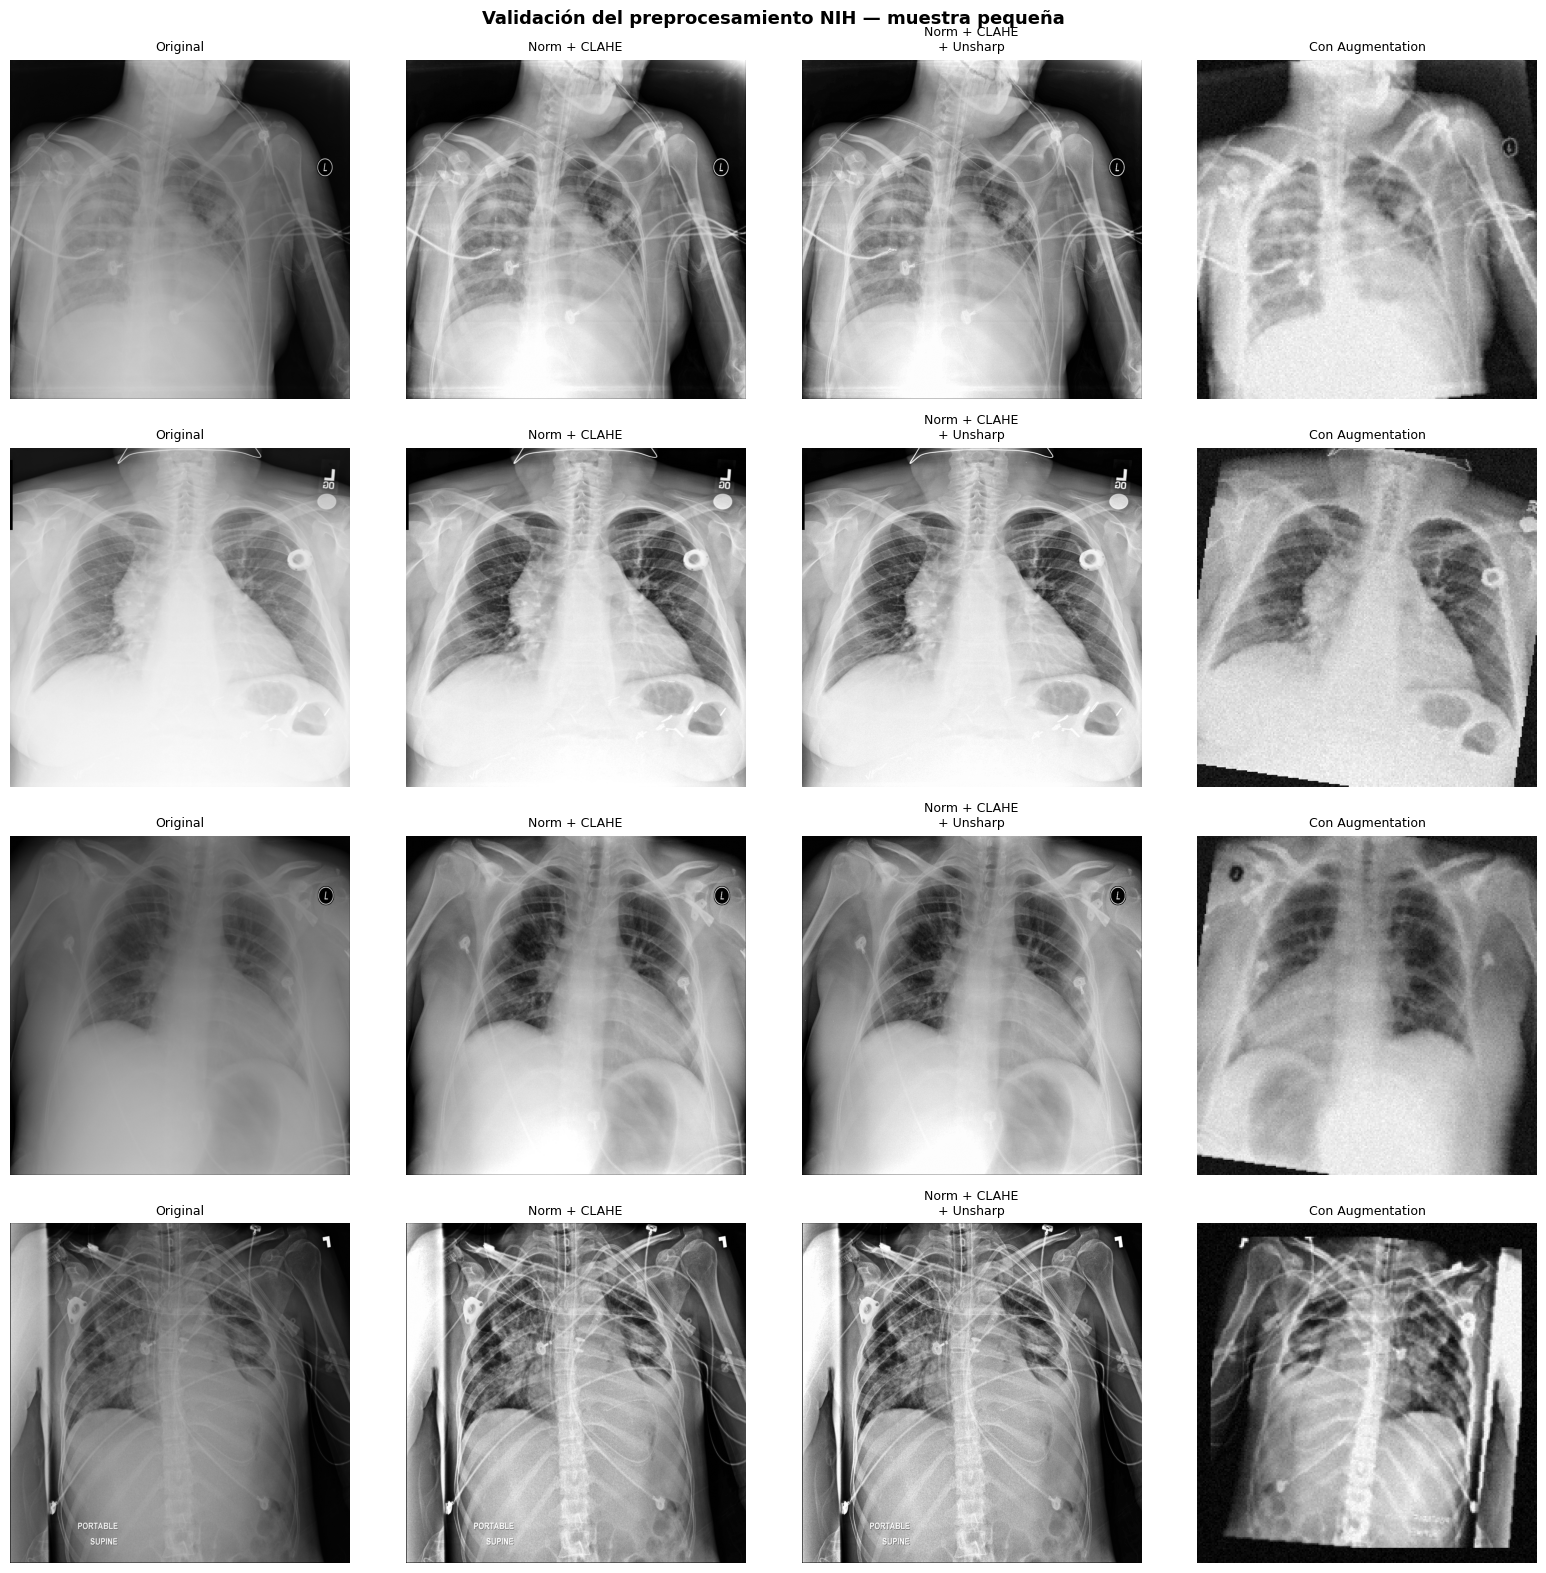

Guardado en /workspace/moe_medical_vision/preprocessing_sample.png


In [25]:
import sys
sys.path.insert(0, '/workspace/moe_medical_vision/src')
from nih_preprocessing_v2 import visualize_preprocessing_sample

visualize_preprocessing_sample(
    nih_root='/workspace/moe_medical_vision/data/raw/nih',
    n_samples=4
)

---
## 2. Experto 1 — NIH ChestX-ray14 (ConvNeXt-Tiny)
**Task 1.3** | Multilabel | 14 clases | BCEWithLogitsLoss

In [26]:
# ============================================================
# EXPERTO 1 — NIH ChestX-ray14  |  Tier F (Fisher 2025 Exact)
# ============================================================
# Parametros EXACTOS de los papers:
#
#  FISHER 2025 (F1=0.803 single model, F1=0.821 ensemble, 14 clases):
#   F1 — Architecture:  ConvNeXt-Tiny in22k_ft_in1k  (IN-21K pretrain)
#   F2 — Loss:          BCEWithLogitsLoss  (sin pos_weight en loss;
#                       Fisher: "weighted BCE discarded in favor of sampling")
#   F3 — Imbalance:     Geometric mean weighted sampler  (Fisher eq. 6.1)
#                       w_i = (∏ 1/freq_d)^(1/k)  para d in enf. presentes
#   F4 — Optimizer:     AdamW  lr=0.0001, weight_decay=1e-4  (uniforme, sin LLRD)
#   F5 — Scheduler:     ReduceLROnPlateau  factor=0.5, patience=5  sobre F1
#   F6 — Augmentation:  SOLO HFlip p=0.5  (Fisher literal: "limited to
#                       random horizontal flips... to preserve anatomical authenticity")
#   F7 — Normalization: ImageNet [0.485,0.456,0.406] / [0.229,0.224,0.225]
#   F8 — Selection:     checkpoints por F1, NO por val_loss
#   F9 — Early stop:    patience=20 epochs  sobre F1
#   F10— Max epochs:    400
#   F11— Batch:         352 @ 224px → aproximado con batch=64 × accum=4 = 256
#
#  DACNET (F1=0.39 sobre 14 clases con DenseNet-121):
#   D1 — Per-class threshold tuning  (DACNet: "significativamente mejoró F1";
#         Fisher lo lista como limitación futura → lo implementamos)
#
#  5-CLASS SUBSET (Manuel nih5 F1=0.5469):
#   M1 — [Atelectasis,Effusion,Infiltration,Mass,Nodule] + filter ≥1 pos
#
#  ADICIONES propias (no en papers, marcadas *):
#   *   — EMA decay=0.999  (mejora tipica +1-3 pts en multilabel medical)
#   *   — BugFix: labels (N,14) en cache; sin Kornia en __getitem__
#         Auto-rebuild de labels obsoletos (N,2)
# ============================================================

import sys, os, cv2, csv, random, copy, torch
import numpy as np
import torch.nn as nn
from pathlib import Path
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor
from PIL import Image
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms
import torchvision.transforms.functional as TF
import torch.nn.functional as F
from tqdm.notebook import tqdm
from sklearn.metrics import f1_score, roc_auc_score
import timm
import json

sys.path.insert(0, '/workspace/moe_medical_vision/src')
from data.datasets import NIHChestXray14Dataset

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
torch.cuda.empty_cache()

# ── Config ───────────────────────────────────────────────────────────────────
DEVICE         = 'cuda'
CHECKPOINT_DIR = Path('/workspace/moe_medical_vision/checkpoints')
METRICS_DIR    = CHECKPOINT_DIR / 'metrics'
SPECIALIST_DIR = CHECKPOINT_DIR / 'specialists'
METRICS_DIR.mkdir(parents=True, exist_ok=True)
SPECIALIST_DIR.mkdir(parents=True, exist_ok=True)
NIH_PATH       = '/workspace/moe_medical_vision/data/raw/nih'
CACHE_DIR      = Path('/workspace/moe_medical_vision/data/cache/nih_clahe_224')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# M1: 5-class subset — NIH14 label order:
#   0=Atelectasis, 1=Cardiomegaly, 2=Effusion, 3=Infiltration,
#   4=Mass, 5=Nodule, 6=Pneumonia, 7=Pneumothorax, ...
SUBSET_INDICES = [0, 2, 3, 4, 5]
CLASS_NAMES    = ['Atelectasis', 'Effusion', 'Infiltration', 'Mass', 'Nodule']
CLASS_SHORT    = ['Atel', 'Effu', 'Infi', 'Mass', 'Nodu']
NUM_CLASSES    = 5

# F4/F9/F10/F11 — Fisher 2025 exact
LR             = 0.0001     # F4: AdamW lr (uniform, no LLRD)
WEIGHT_DECAY   = 1e-3       # anti-ovf2: 5e-4→1e-3 (ep22→32 overfit)
BATCH_SIZE     = 64         # F11: 64 × accum 4 = 256 eff  (Fisher: 352)
ACCUM_STEPS    = 2          # F11 (reduced 4→2 for implicit regularization)
EPOCHS         = 400        # F10: Fisher max
PATIENCE       = 10         # balanced: back to 10 (short S1 means fewer epochs needed)
LR_PATIENCE    = 5          # F5: Fisher ReduceLROnPlateau patience
LR_FACTOR      = 0.5        # F5: Fisher "reduced by 50% when metric plateaued"

SEED           = 42
NUM_WORKERS    = 8
PREFETCH       = 4
EMA_DECAY      = 0.999      # * (our addition, not in Fisher)
MIXUP_ALPHA    = 0.6        # anti-ovf2: 0.4→0.6 (stronger multilabel regularization)
STAGE1_EPOCHS  = 3          # balanced: brief head init (head plateaued ep14 anyway)
HEAD_LR_S1    = 1e-3        # * head-only LR during freeze (F3)
HEAD_LR_S2    = 3e-4        # balanced: 2e-4→3e-4 (head needs to track bb)
HEAD_LR_S3    = 1e-4        # P2: head LR Stage 3 (full backbone unfrozen)
BB_LR_S2      = 2e-5        # anti-ovf2: 3e-5→2e-5 (cosine decay from here)
BB_LR_S3      = 1e-5        # P2: deep backbone LR Stage 3 (reduce)
BB_EARLY_LR_S3 = 2e-6       # P2: early backbone LR Stage 3 (stem+stages.0+1)
STAGE2_EPOCHS  = 999        # anti-ovf: Stage 3 never triggers

USE_GAMMA      = True
GAMMA_VALUE    = 1.2
CACHE_TAG      = 'clahe_unsharp' + (f'_gamma{GAMMA_VALUE}' if USE_GAMMA else '')

torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Backbone family (switch here to A/B test) ────────────────────────────────
# 'swin'     → Swin-Tiny IN-22K (global attention, better for context-dependent patos)
# 'convnext' → ConvNeXt-Tiny IN-22K (local convolution, better for focal lesions)
BACKBONE_FAMILY = 'convnext'
print(f'[config] Backbone family: {BACKBONE_FAMILY}')


# ── 1. Raw preprocessor  (only for cache builder) ────────────────────────────
class RawCLAHEPreprocess:
    _GAMMA_LUT       = None
    _GAMMA_LUT_value = None

    @classmethod
    def _get_gamma_lut(cls, gamma: float) -> np.ndarray:
        if cls._GAMMA_LUT is None or cls._GAMMA_LUT_value != gamma:
            inv = 1.0 / max(gamma, 1e-3)
            cls._GAMMA_LUT = np.array(
                [((i / 255.0) ** inv) * 255 for i in range(256)], dtype=np.uint8
            )
            cls._GAMMA_LUT_value = gamma
        return cls._GAMMA_LUT

    def __call__(self, img: Image.Image) -> np.ndarray:
        arr = np.array(img.convert('L'))
        p2, p98 = np.percentile(arr, 2), np.percentile(arr, 98)
        arr = np.clip(arr, p2, p98)
        arr = ((arr - p2) / (p98 - p2 + 1e-6) * 255).astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        arr = clahe.apply(arr)
        if USE_GAMMA:
            lut = self._get_gamma_lut(GAMMA_VALUE)
            arr = cv2.LUT(arr, lut)
        blurred = cv2.GaussianBlur(arr.astype(np.float32), (0, 0), 1.0)
        sharp = arr.astype(np.float32) + 0.5 * (arr.astype(np.float32) - blurred)
        arr = np.clip(sharp, 0, 255).astype(np.uint8)
        arr_3ch = np.stack([arr, arr, arr], axis=-1)
        return cv2.resize(arr_3ch, (224, 224), interpolation=cv2.INTER_LINEAR)


# ── 2. Cache builder  (*: labels (N,14) fix; labels-only rebuild si obsoleto) ─
def build_cache(split: str, num_threads: int = 8, chunk: int = 512, flush_every: int = 1024):
    cache_file  = CACHE_DIR / f'nih_{split}_224_{CACHE_TAG}.dat'
    labels_file = CACHE_DIR / f'nih_{split}_labels.npy'
    meta_file   = CACHE_DIR / f'nih_{split}_meta_{CACHE_TAG}.npz'

    raw_ds = NIHChestXray14Dataset(NIH_PATH, split=split, transform=RawCLAHEPreprocess())
    N = len(raw_ds)

    images_ok = False
    if cache_file.exists() and meta_file.exists():
        try:
            if int(np.load(meta_file)['N']) == N:
                images_ok = True
        except Exception:
            pass

    labels_ok = False
    if labels_file.exists() and images_ok:
        try:
            if np.load(labels_file).shape == (N, 14):
                labels_ok = True
        except Exception:
            pass

    if images_ok and labels_ok:
        print(f'[cache {split}] HIT  | N={N} | {cache_file.stat().st_size/1e9:.2f} GB')
        return cache_file, labels_file, N

    if images_ok and not labels_ok:
        print(f'[cache {split}] Labels obsoletos (N,2) → rebuild labels solamente ...')
        labels = np.zeros((N, 14), dtype=np.float32)
        def get_label(i):
            s = raw_ds[i]
            return i, s['label'].numpy().astype(np.float32)
        with ThreadPoolExecutor(max_workers=num_threads) as ex:
            with tqdm(total=N, desc=f'labels {split}', leave=False) as pbar:
                for start in range(0, N, chunk):
                    end = min(start + chunk, N)
                    res = list(ex.map(get_label, range(start, end)))
                    for i, lbl in res:
                        labels[i] = lbl
                    del res
                    pbar.update(end - start)
        np.save(labels_file, labels)
        print(f'[cache {split}] Labels OK | shape={labels.shape}')
        return cache_file, labels_file, N

    print(f'[cache {split}] MISS | building {N} samples (threads={num_threads}, chunk={chunk}) ...')
    mmap   = np.memmap(cache_file, dtype=np.uint8, mode='w+', shape=(N, 224, 224, 3))
    labels = np.zeros((N, 14), dtype=np.float32)

    def process(i):
        s = raw_ds[i]
        return i, s['image'], s['label'].numpy().astype(np.float32)

    written = 0
    with ThreadPoolExecutor(max_workers=num_threads) as ex:
        with tqdm(total=N, desc=f'cache {split}', leave=False) as pbar:
            for start in range(0, N, chunk):
                end = min(start + chunk, N)
                results = list(ex.map(process, range(start, end)))
                for i, img_arr, lbl in results:
                    mmap[i] = img_arr
                    labels[i] = lbl
                    written += 1
                    if written % flush_every == 0:
                        mmap.flush()
                del results
                pbar.update(end - start)

    mmap.flush()
    del mmap
    np.save(labels_file, labels)
    np.savez(meta_file, N=N, H=224, W=224, C=3, split=split)
    print(f'[cache {split}] DONE | {cache_file.stat().st_size/1e9:.2f} GB')
    return cache_file, labels_file, N


# ── 3. Fisher eq. 6.1 Geometric Mean Weighted Sampler  (F3) ─────────────────
def build_geometric_sampler(labels: np.ndarray) -> WeightedRandomSampler:
    """Fisher 2025 eq. 6.1:
       w_i = ( ∏_{d in present(i)} (1/freq_d) )^(1/k)
    Geometric mean of inverse frequencies for diseases present in image i.
    Prevents over-sampling of multi-label images vs arithmetic mean.
    """
    freq     = labels.mean(axis=0)                      # (C,) prevalence
    inv_freq = 1.0 / np.clip(freq, 1e-4, None)          # (C,) inverse freq

    n = len(labels)
    w = np.zeros(n, dtype=np.float64)
    for i in range(n):
        present = np.where(labels[i] > 0)[0]
        if len(present) == 0:
            w[i] = 1.0
        else:
            prod    = np.prod(inv_freq[present])         # product of inv_freq for present diseases
            w[i]    = prod ** (1.0 / len(present))       # k-th root = geometric mean

    w = np.clip(w, 0.0, np.percentile(w, 95))           # cap outliers (multi-rare-disease images)
    return WeightedRandomSampler(w.tolist(), num_samples=n, replacement=True)


# ── 3a. LabelSmoothBCE  (R3: prevents overconfident train predictions) ─────
class LabelSmoothBCE(nn.Module):
    """BCEWithLogitsLoss + label smoothing eps.
    targets 0 -> eps/2, targets 1 -> 1 - eps/2.
    Prevents overconfident logits that push train_loss near zero."""
    def __init__(self, pos_weight=None, eps=0.05):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='mean')
        self.eps = eps

    def forward(self, logits, targets):
        targets_smooth = targets * (1 - self.eps) + (1 - targets) * (self.eps / 2)
        return self.bce(logits, targets_smooth)


# ── 3b. AsymmetricLoss  (Ridnik 2021 · gn=2,gp=1,clip=0.03 = Manuel winner) ──
# * not in Fisher (uses BCE); proved superior in Manuel nih5 experiments
class AsymmetricLoss(nn.Module):
    """Downweights easy negatives more aggressively than Focal.
    gamma_neg=2: heavy penalty on easy true-negatives (dominant class).
    gamma_pos=1: light penalty on missed true-positives.
    clip=0.03: shifts neg prob upward, prevents over-suppression."""
    def __init__(self, gamma_neg=2.0, gamma_pos=1.0, clip=0.03, eps=1e-8):
        super().__init__()
        self.gamma_neg, self.gamma_pos = gamma_neg, gamma_pos
        self.clip, self.eps = clip, eps

    def forward(self, logits, targets):
        prob   = torch.sigmoid(logits)
        xs_pos = prob
        xs_neg = (1.0 - prob + self.clip).clamp(max=1) if self.clip > 0 else 1.0 - prob
        los_p  = targets       * torch.log(xs_pos.clamp(min=self.eps))
        los_n  = (1 - targets) * torch.log(xs_neg.clamp(min=self.eps))
        loss   = los_p + los_n
        pt     = xs_pos * targets + (1.0 - prob) * (1 - targets)
        gamma  = self.gamma_pos * targets + self.gamma_neg * (1 - targets)
        return -(loss * (1 - pt).pow(gamma)).mean()


# ── 3c. Mixup  (M1: anti-memorization for multilabel medical imaging) ─────────
def mixup_batch(x: torch.Tensor, y: torch.Tensor,
                alpha: float = 0.4) -> tuple:
    """Mix two random samples in a batch.
    Lambda ~ Beta(alpha, alpha). Works with soft/hard multilabel targets.
    Applied only in Stage 2 (backbone active); Stage 1 uses head-warmup only."""
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(x.size(0), device=x.device)
    x_mix = lam * x + (1.0 - lam) * x[idx]
    y_mix = lam * y + (1.0 - lam) * y[idx]
    return x_mix, y_mix


# ── 4. Dataset  (F6: only HFlip; F7: ImageNet norms; *: no Kornia; M1: filter) ─
class CachedNIHDataset(Dataset):
    # F7: Fisher uses architecture-specific normalization = ImageNet
    _MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    _STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __init__(self, cache_path, labels_path, N_total, split='train',
                 subset_indices=None, filter_positives=True):
        self.cache_path  = str(cache_path)
        self.N_total     = int(N_total)
        self.split       = split
        subset_idx       = subset_indices if subset_indices is not None else list(range(14))

        all_labels    = np.load(labels_path)          # (N, 14)
        subset_labels = all_labels[:, subset_idx]     # (N, 5)

        if filter_positives:
            mask         = subset_labels.sum(axis=1) > 0
            self.indices = np.where(mask)[0]
        else:
            self.indices = np.arange(len(all_labels))

        self.labels = subset_labels[self.indices].astype(np.float32)
        self._mmap  = None

        # F1 fix: Manuel aug recipe (hflip+rotate+brightness+contrast)
        # Fisher HFlip-only is for 86k samples; our 25k needs more augmentation
        self.is_train = (split == 'train')

    def _lazy_init(self):
        if self._mmap is None:
            self._mmap = np.memmap(
                self.cache_path, dtype=np.uint8, mode='r',
                shape=(self.N_total, 224, 224, 3))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        self._lazy_init()
        arr    = np.asarray(self._mmap[self.indices[idx]])
        tensor = torch.from_numpy(arr.copy()).permute(2, 0, 1).float().div_(255.0)
        # * No Kornia — cache already has CLAHE+Gamma+Unsharp
        if self.is_train:
            # B2: DACNet aug — RandomResizedCrop first (scale 0.85-1.0)
            scale = 0.85 + torch.rand(1).item() * 0.15   # uniform(0.85, 1.0)
            crop_size = int(round(224 * (scale ** 0.5)))  # keep aspect ~1
            # manual crop params (TF is functional, not transforms)
            _, _H, _W = tensor.shape
            top  = int(torch.randint(0, max(_H - crop_size, 0) + 1, (1,)).item())
            left = int(torch.randint(0, max(_W - crop_size, 0) + 1, (1,)).item())
            tensor = TF.resized_crop(tensor, top, left, crop_size, crop_size, size=224)
            # F1: Manuel aug (hflip+rotate+brightness+contrast)
            if torch.rand(1).item() < 0.5:
                tensor = TF.hflip(tensor)
            angle = (torch.rand(1).item() * 20) - 10  # uniform(-10, 10)
            tensor = TF.rotate(tensor, angle)
            bf = 0.9 + torch.rand(1).item() * 0.2    # uniform(0.9, 1.1)
            tensor = TF.adjust_brightness(tensor, bf)
            cf = 0.9 + torch.rand(1).item() * 0.2    # uniform(0.9, 1.1)
            tensor = TF.adjust_contrast(tensor, cf)
        # F7: ImageNet normalization
        tensor = (tensor - self._MEAN) / self._STD
        return {
            'image': tensor,
            'label': torch.from_numpy(self.labels[idx]),
        }

    def get_pos_weight(self) -> torch.Tensor:
        pos = self.labels.sum(axis=0).astype('float64')
        neg = float(len(self)) - pos
        return torch.tensor(np.where(pos > 0, neg / pos, 1.0), dtype=torch.float32)


# ── 5. Model: ConvNeXt-Tiny in22k_ft_in1k  (F1: Fisher architecture) ─────────
class CXRBackbone(nn.Module):
    """Family-agnostic backbone wrapper.
    Family is chosen via BACKBONE_FAMILY global ('swin' or 'convnext').
    Each family has:
      - ordered candidate IDs (IN-22K first, IN-1K fallback)
      - unfreeze keys for stage2 (deep-only) and rare (deep + penultimate)
      - recommended drop_path rate"""

    _FAMILY = {
        'convnext': {
            'candidates': [
                'convnext_tiny.fb_in22k_ft_in1k',
                'convnext_tiny.in22k_ft_in1k',
                'convnextv2_tiny.fcmae_ft_in22k_in1k',
                'convnextv2_nano.fcmae_ft_in22k_in1k',
                'convnext_tiny.fb_in1k',
                'convnext_tiny',
            ],
            'deep_keys':  ('backbone.stages.3', 'backbone.norm_pre'),
            'rare_keys':  ('backbone.stages.2', 'backbone.stages.3', 'backbone.norm_pre'),
            'drop_path':  0.10,
            'dropout':    0.4,
        },
        'swin': {
            'candidates': [
                'swin_tiny_patch4_window7_224.ms_in22k_ft_in1k',
                'swin_tiny_patch4_window7_224.ms_in22k',
                'swinv2_tiny_window16_256.ms_in1k',                # 256 input (auto-resize)
                'swin_tiny_patch4_window7_224.ms_in1k',
                'swin_tiny_patch4_window7_224',
            ],
            # Swin timm param names: layers.{0..3}.blocks..., norm (final)
            'deep_keys':  ('backbone.layers.3', 'backbone.norm'),
            'rare_keys':  ('backbone.layers.2', 'backbone.layers.3', 'backbone.norm'),
            'drop_path':  0.20,   # Swin needs more regularization than ConvNeXt
            'dropout':    0.4,
        },
    }

    def __init__(self, num_classes=5, family=None):
        super().__init__()
        family = family or BACKBONE_FAMILY
        if family not in self._FAMILY:
            raise ValueError(f'unknown family: {family}')
        cfg = self._FAMILY[family]
        self.family = family
        self._deep_keys = cfg['deep_keys']
        self._rare_keys = cfg['rare_keys']

        self.backbone = None
        for model_id in cfg['candidates']:
            try:
                self.backbone = timm.create_model(
                    model_id, pretrained=True,
                    num_classes=0, global_pool='avg',
                    drop_path_rate=cfg['drop_path'])
                tag = 'IN-22K' if '22k' in model_id else 'IN-1K'
                print(f'  Backbone: {model_id} ({tag}, family={family})')
                break
            except Exception:
                continue
        if self.backbone is None:
            raise RuntimeError(f'Could not load any {family} backbone')

        self.head = nn.Sequential(
            nn.Dropout(cfg['dropout']),
            nn.Linear(self.backbone.num_features, num_classes),
        )

    def get_unfreeze_keys(self, rare=False):
        return self._rare_keys if rare else self._deep_keys

    def forward(self, x):
        return self.head(self.backbone(x))


# Backwards-compat alias (old code refers to ConvNeXtCXR)
ConvNeXtCXR = CXRBackbone


# ── 6. EMA  (* our addition, not in Fisher) ───────────────────────────────────
class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.decay  = decay
        self.module = copy.deepcopy(model).eval()
        for p in self.module.parameters():
            p.requires_grad = False

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, ema_v in self.module.state_dict().items():
            m_v = msd[k]
            if ema_v.dtype.is_floating_point:
                ema_v.mul_(self.decay).add_(m_v.detach(), alpha=1.0 - self.decay)
            else:
                ema_v.copy_(m_v)


# ── 7. Binary Focal Loss (for rare-class specialists) ────────────────────────
class BinaryFocalLoss(nn.Module):
    """BCE + focal modulation for binary tasks.
    gamma=1.5 default (mild); gamma=2.5 for rare classes (Mass, Nodule).
    pos_weight balances class imbalance (NIH: ~1:7 for rare classes)."""
    def __init__(self, pos_weight=None, gamma=1.5, label_smoothing=0.02):
        super().__init__()
        self.pos_weight = pos_weight
        self.gamma = gamma
        self.eps = label_smoothing

    def forward(self, logits, targets):
        # label smoothing (prevents overconfident 0/1 targets)
        t = targets * (1 - self.eps) + (1 - targets) * (self.eps / 2)
        bce = F.binary_cross_entropy_with_logits(
            logits, t, pos_weight=self.pos_weight, reduction='none')
        pt  = torch.exp(-bce.clamp(max=10))
        return ((1 - pt) ** self.gamma * bce).mean()


# ── 8. Binary dataset — propuesta EXACTA del profesor ────────────────────────
class BinaryCachedNIHDataset(Dataset):
    """Modes:
      - mode='global':
          pos = imgs with any positive in 5-class subset
          neg = imgs with NoFinding (all 14 labels = 0)
          (prof L52: "la existencia vs la no existencia")
      - mode='one_vs_rest'  (ALINEA train/val distribution):
          pos = imgs with this disease present in 5-class subset (exclusive or not)
          neg = imgs with OTHER 5-class diseases present (hard negatives) +
                NoFinding subsample (prof L52 reference negative)
          → La distribución en train es la misma que en filtered val
      - mode='disease_exclusive'  (legacy, mantenido por compatibilidad):
          pos = imgs with ONLY this disease in 5-class subset
          neg = NoFinding
      - mode='val_multilabel':
          inferencia final: val filtrado con label binario de esta clase
    Submuestreo de NoFinding en train (prof L17/L19): neg_ratio controla el
    ratio max de negativos:positivos."""
    _MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    _STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __init__(self, cache_path, labels_path, N_total, split, mode,
                 nih14_idx=None, neg_ratio=2.0, seed=42, rare_erase=False):
        self.cache_path = str(cache_path)
        self.N_total    = int(N_total)
        self.is_train   = (split == 'train')
        self.rare_erase = bool(rare_erase) and self.is_train
        all_labels      = np.load(labels_path)   # (N, 14)
        subset          = all_labels[:, SUBSET_INDICES]   # (N, 5)

        nofinding_mask = (all_labels.sum(axis=1) == 0)    # true NoFinding in NIH14

        if mode == 'global':
            pos_mask = subset.sum(axis=1) > 0              # any of our 5 classes
            neg_mask = nofinding_mask
        elif mode == 'one_vs_rest':
            if nih14_idx is None:
                raise ValueError('one_vs_rest requires nih14_idx')
            idx_in_5 = SUBSET_INDICES.index(nih14_idx)
            # pos = this disease present in 5-class (exclusive or with co-occurrence)
            pos_mask = (subset[:, idx_in_5] == 1)
            # neg = OTHER 5-class diseases (hard negatives, in-distribution)
            #       + NoFinding (easy negatives, prof L52 reference)
            hard_neg = (subset[:, idx_in_5] == 0) & (subset.sum(axis=1) > 0)
            neg_mask = hard_neg | nofinding_mask
            self._hard_neg_mask = hard_neg      # for diagnostics
            self._easy_neg_mask = nofinding_mask
        elif mode == 'disease_exclusive':
            if nih14_idx is None:
                raise ValueError('disease_exclusive requires nih14_idx')
            idx_in_5 = SUBSET_INDICES.index(nih14_idx)
            # Exclusive in 5-class (other 4 classes = 0 in our subset)
            pos_mask = (subset[:, idx_in_5] == 1) & (subset.sum(axis=1) == 1)
            neg_mask = nofinding_mask
        elif mode == 'val_multilabel':
            # Val: use filtered val (≥1 positive in 5-class) for fair macro F1 eval
            mask = subset.sum(axis=1) > 0
            self.indices = np.where(mask)[0]
            self.labels  = all_labels[self.indices, nih14_idx].astype(np.float32).reshape(-1, 1)
            self._mmap   = None
            return
        else:
            raise ValueError(f'unknown mode: {mode}')

        pos_idx = np.where(pos_mask)[0]
        neg_idx = np.where(neg_mask)[0]

        # Subsample negatives in TRAIN split only (val keeps full distribution)
        if self.is_train and neg_ratio > 0 and len(neg_idx) > neg_ratio * len(pos_idx):
            n_neg = int(neg_ratio * len(pos_idx))
            rng = np.random.default_rng(seed + (nih14_idx or 999))
            neg_idx = rng.choice(neg_idx, size=n_neg, replace=False)

        self.indices = np.concatenate([pos_idx, neg_idx])
        labels_bin = np.zeros(len(self.indices), dtype=np.float32)
        labels_bin[:len(pos_idx)] = 1.0
        self.labels = labels_bin.reshape(-1, 1)
        self._mmap  = None

    def _lazy_init(self):
        if self._mmap is None:
            self._mmap = np.memmap(self.cache_path, dtype=np.uint8, mode='r',
                                   shape=(self.N_total, 224, 224, 3))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        self._lazy_init()
        arr    = np.asarray(self._mmap[self.indices[idx]])
        tensor = torch.from_numpy(arr.copy()).permute(2, 0, 1).float().div_(255.0)
        if self.is_train:
            # v9: rare classes use wider scale range for more zoom variation
            if self.rare_erase:
                scale = 0.75 + torch.rand(1).item() * 0.25   # [0.75, 1.0]
            else:
                scale = 0.85 + torch.rand(1).item() * 0.15   # [0.85, 1.0]
            crop_size = int(round(224 * (scale ** 0.5)))
            _, _H, _W = tensor.shape
            top  = int(torch.randint(0, max(_H - crop_size, 0) + 1, (1,)).item())
            left = int(torch.randint(0, max(_W - crop_size, 0) + 1, (1,)).item())
            tensor = TF.resized_crop(tensor, top, left, crop_size, crop_size, size=224)
            if torch.rand(1).item() < 0.5:
                tensor = TF.hflip(tensor)
            angle = (torch.rand(1).item() * 20) - 10
            tensor = TF.rotate(tensor, angle)
            bf = 0.9 + torch.rand(1).item() * 0.2
            tensor = TF.adjust_brightness(tensor, bf)
            cf = 0.9 + torch.rand(1).item() * 0.2
            tensor = TF.adjust_contrast(tensor, cf)
            if self.rare_erase and torch.rand(1).item() < 0.25:
                # RandomErasing for rare classes: mask a random patch to force
                # model to use diverse image regions (reduces nodule-memorization)
                _, _H, _W = tensor.shape
                eh = int(_H * (0.08 + torch.rand(1).item() * 0.12))
                ew = int(_W * (0.08 + torch.rand(1).item() * 0.12))
                ty = int(torch.randint(0, max(_H - eh, 1), (1,)).item())
                tx = int(torch.randint(0, max(_W - ew, 1), (1,)).item())
                tensor[:, ty:ty+eh, tx:tx+ew] = torch.rand(3, eh, ew)
        tensor = (tensor - self._MEAN) / self._STD
        return {'image': tensor, 'label': torch.from_numpy(self.labels[idx])}

    def get_pos_weight(self):
        pos = float(self.labels.sum())
        neg = float(len(self)) - pos
        return torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32)


# ── 9. Per-specialist configuration — professor's 6-model proposal ──────────
# Cada especialista: BINARIO (NoFinding vs X) con NoFinding submuestreado 2:1
# (name,         mode,                 nih14_idx, lr_head, lr_bb, wd, focal_g, mixup, max_ep, pat)
SPECIALIST_CONFIGS = [
    # Global: ligeramente más épocas (estaba mejorando al final)
    ('Global',       'global',      None, 1e-3, 2e-5, 5e-4, 1.0, 0.3, 18, 6),
    # Disease specialists comunes (one_vs_rest alinea train/val)
    ('Atelectasis',  'one_vs_rest', 0,    1e-3, 2e-5, 5e-4, 1.5, 0.3, 28, 8),   # v7: still improving at ep20
    ('Effusion',     'one_vs_rest', 2,    1e-3, 2e-5, 5e-4, 1.5, 0.3, 28, 8),   # v6: aún subía en ep20 (0.5967->0.6042)
    ('Infiltration', 'one_vs_rest', 3,    1e-3, 2e-5, 5e-4, 1.5, 0.3, 18, 6),  # v6: revert v5 rescue (colapsó ep1)
    # Rare classes: γ=1.5 (no 2.5, underfit), mixup=0.2 (cleaner), más ep, unfreeze stages.2
    ('Mass',         'one_vs_rest', 4,    1e-3, 3e-5, 5e-4, 1.5, 0.2, 28, 8),   # rare v3
    ('Nodule',       'one_vs_rest', 5,    1e-3, 3e-5, 5e-4, 1.5, 0.2, 28, 8),   # rare v3
]
# Classes que deben desbloquear stages.2 (penúltimo stage, +capacidad para features raros)
RARE_CLASSES = {'Mass', 'Nodule'}
# Swin needs longer head warmup (transformer embeddings need more alignment time)
STAGE1_EPOCHS_SPEC = 3 if BACKBONE_FAMILY == 'swin' else 2
NEG_RATIO          = 2.0 # NoFinding submuestreado a 2x positivos (prof L17/L19)
# Swin also benefits from lower backbone LR (more sensitive to aug/rotation)
BB_LR_SCALE        = 0.5 if BACKBONE_FAMILY == 'swin' else 1.0


# ── 10. Train a single specialist ────────────────────────────────────────────
def train_specialist(name, mode, nih14_idx, lr_head, lr_bb, wd,
                     focal_gamma, mixup_a, max_ep, patience,
                     train_cache, train_labels_file, N_train,
                     val_cache,   val_labels_file,   N_val,
                     batch_size=64, accum_steps=2, num_workers=8,
                     seed_tag: str = ''):
    _is_rare_class = name in RARE_CLASSES
    # v8: per-specialist neg_ratio — rare=3 (higher pos_weight), rest=default
    # (v7 Infi=4 reverted: +66% train time for 0.0 F1 gain)
    _neg_ratio = 3.0 if _is_rare_class else NEG_RATIO
    train_ds = BinaryCachedNIHDataset(train_cache, train_labels_file, N_train, 'train',
                                      mode=mode, nih14_idx=nih14_idx, neg_ratio=_neg_ratio,
                                      rare_erase=_is_rare_class)
    val_ds   = BinaryCachedNIHDataset(val_cache,   val_labels_file,   N_val,   'val',
                                      mode=mode, nih14_idx=nih14_idx, neg_ratio=0.0)
    # Train-eval: mismo subset que train pero sin augmentation (para BCE limpio)
    train_eval_ds = BinaryCachedNIHDataset(train_cache, train_labels_file, N_train, 'val',
                                           mode=mode, nih14_idx=nih14_idx, neg_ratio=_neg_ratio)
    # Limita train_eval a ~1024 muestras aleatorias (cost-bound)
    _rng = np.random.default_rng(123)
    if len(train_eval_ds) > 1024:
        _keep = _rng.choice(len(train_eval_ds), 1024, replace=False)
        train_eval_ds.indices = train_eval_ds.indices[_keep]
        train_eval_ds.labels  = train_eval_ds.labels[_keep]

    n_pos_tr = int(train_ds.labels.sum()); n_neg_tr = len(train_ds) - n_pos_tr
    n_pos_vl = int(val_ds.labels.sum());   n_neg_vl = len(val_ds)   - n_pos_vl
    print(f'  Train: {len(train_ds)} (pos {n_pos_tr}/{n_neg_tr}) | '
          f'Val: {len(val_ds)} (pos {n_pos_vl}/{n_neg_vl})')

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True,
        persistent_workers=num_workers > 0, prefetch_factor=4, drop_last=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size*2, shuffle=False,
        num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)
    train_eval_loader = DataLoader(train_eval_ds, batch_size=batch_size*2, shuffle=False,
        num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2)
    # [FIX v3] Filtered-multilabel val for thr calibration (matches inference distribution)
    # Only built for disease specialists (Global has no multilabel equivalent)
    mlval_loader = None
    if mode == 'one_vs_rest':
        mlval_ds = BinaryCachedNIHDataset(val_cache, val_labels_file, N_val, 'val',
                                          mode='val_multilabel', nih14_idx=nih14_idx, neg_ratio=0.0)
        mlval_loader = DataLoader(mlval_ds, batch_size=batch_size*2, shuffle=False,
            num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2)
        print(f'  Filtered-ML val: {len(mlval_ds)} (pos {int(mlval_ds.labels.sum())}/'
              f'{len(mlval_ds)-int(mlval_ds.labels.sum())}) for thr calibration')

    model = ConvNeXtCXR(num_classes=1).to(DEVICE)
    pos_weight = train_ds.get_pos_weight().to(DEVICE)
    print(f'  pos_weight: {pos_weight.item():.3f}  |  focal gamma: {focal_gamma}')

    criterion_s1 = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    criterion_s2 = BinaryFocalLoss(pos_weight=pos_weight, gamma=focal_gamma)
    criterion    = criterion_s1
    stage        = 1

    head_params    = [p for n, p in model.named_parameters() if n.startswith('head')]
    # v6: all disease specialists get stages.2 unfreeze (Global stays shallow).
    # Motivated by negative BCE gap across 4/5 classes in v5 = underfitting everywhere.
    _use_deep      = name != 'Global'
    _deep_keys     = model.get_unfreeze_keys(rare=_use_deep)
    bb_deep_params = [p for n, p in model.named_parameters()
                      if not n.startswith('head') and any(n.startswith(k) for k in _deep_keys)]
    bb_other       = [p for n, p in model.named_parameters()
                      if not n.startswith('head') and not any(n.startswith(k) for k in _deep_keys)]
    if _use_deep:
        _tier = 'rare+erase' if _is_rare_class else 'disease'
        print(f'    [{_tier}] stages.2 unfreeze (v6: deep-unfreeze for all non-Global)')
    print(f'    Unfreeze keys ({model.family}, deep={_use_deep}): {_deep_keys}')
    for p in bb_deep_params + bb_other:
        p.requires_grad = False
    optimizer = torch.optim.AdamW(
        [{'params': head_params, 'lr': lr_head, 'weight_decay': wd}])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3, min_lr=1e-7)
    scaler = GradScaler('cuda')
    ema    = ModelEMA(model, decay=EMA_DECAY)

    best_f1, best_thr, best_epoch, best_auc, no_improve = 0.0, 0.5, 0, 0.0, 0
    ckpt_path = SPECIALIST_DIR / f'expert1_{name}{seed_tag}_best.pth'

    for epoch in range(1, max_ep + 1):
        if epoch == STAGE1_EPOCHS_SPEC + 1:
            for p in bb_deep_params:
                p.requires_grad = True
            optimizer.param_groups[0]['lr'] = lr_head * 0.3
            optimizer.add_param_group({'params': bb_deep_params, 'lr': lr_bb * BB_LR_SCALE, 'weight_decay': wd})
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=max_ep - STAGE1_EPOCHS_SPEC, eta_min=1e-7)
            criterion  = criterion_s2
            stage      = 2
            no_improve = 0
            print(f'    >> STAGE 2 (ep{epoch}): unfreeze stages.3+norm_pre, lr_bb={lr_bb:.0e}, focal')

        model.train()
        total_loss  = 0.0
        accum_count = 0
        optimizer.zero_grad()
        for batch in train_loader:
            x = batch['image'].to(DEVICE, non_blocking=True)
            y = batch['label'].to(DEVICE, non_blocking=True)
            if stage == 2 and mixup_a > 0:
                lam = float(np.random.beta(mixup_a, mixup_a))
                idx = torch.randperm(x.size(0), device=x.device)
                if torch.rand(1).item() < 0.5:
                    # CutMix: paste random patch (preserves spatial features for CXR)
                    _, _, _cH, _cW = x.shape
                    rh = int(_cH * np.sqrt(1.0 - lam))
                    rw = int(_cW * np.sqrt(1.0 - lam))
                    cy, cx = np.random.randint(0, _cH), np.random.randint(0, _cW)
                    y1, y2 = max(0, cy - rh // 2), min(_cH, cy + rh // 2)
                    x1, x2 = max(0, cx - rw // 2), min(_cW, cx + rw // 2)
                    x[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
                    lam = 1.0 - float((y2 - y1) * (x2 - x1)) / float(_cH * _cW)
                else:
                    # MixUp: linear interpolation (global regularization)
                    x = lam * x + (1.0 - lam) * x[idx]
                y = lam * y + (1.0 - lam) * y[idx]
            with autocast('cuda'):
                loss = criterion(model(x), y) / accum_steps
            scaler.scale(loss).backward()
            accum_count += 1
            if accum_count == accum_steps:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update()
                optimizer.zero_grad()
                accum_count = 0
                ema.update(model)
            total_loss += loss.item() * accum_steps
        if accum_count > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
            optimizer.zero_grad()
            ema.update(model)

        avg_loss = total_loss / max(len(train_loader), 1)

        # Eval with per-epoch threshold tuning + honest BCE gap (train vs val)
        ema.module.eval()
        all_p, all_l = [], []
        sum_bce_vl = 0.0; n_vl = 0
        with torch.no_grad():
            for batch in val_loader:
                yb = batch['label'].to(DEVICE, non_blocking=True)
                with autocast('cuda'):
                    logits = ema.module(batch['image'].to(DEVICE, non_blocking=True))
                lf = logits.float()
                sum_bce_vl += F.binary_cross_entropy_with_logits(lf, yb, reduction='sum').item()
                n_vl       += yb.numel()
                all_p.append(torch.sigmoid(lf).cpu().numpy().flatten())
                all_l.append(batch['label'].numpy().flatten())
        # BCE on train sample (no aug, no mixup, no pos_weight, no smoothing)
        sum_bce_tr = 0.0; n_tr = 0
        with torch.no_grad():
            for batch in train_eval_loader:
                yb = batch['label'].to(DEVICE, non_blocking=True)
                with autocast('cuda'):
                    logits = ema.module(batch['image'].to(DEVICE, non_blocking=True))
                sum_bce_tr += F.binary_cross_entropy_with_logits(
                    logits.float(), yb, reduction='sum').item()
                n_tr += yb.numel()
        bce_vl = sum_bce_vl / max(n_vl, 1)
        bce_tr = sum_bce_tr / max(n_tr, 1)
        gap    = bce_vl - bce_tr   # positivo=overfit, negativo=underfit
        y_prob = np.concatenate(all_p); y_true = np.concatenate(all_l)
        # Specialist-val F1 (one_vs_rest distribution)
        grid = np.arange(0.05, 0.95 + 1e-9, 0.01)
        f1_spec, thr_spec = -1.0, 0.5
        for t in grid:
            f = f1_score(y_true, (y_prob >= t).astype(np.int8), zero_division=0)
            if f > f1_spec:
                f1_spec, thr_spec = f, float(t)
        try:    auc_ep = float(roc_auc_score(y_true, y_prob))
        except Exception: auc_ep = 0.0

        # [FIX v3] Calibrate thr on filtered-ML val (matches inference distribution)
        if mlval_loader is not None:
            mlp, mll = [], []
            with torch.no_grad():
                for batch in mlval_loader:
                    with autocast('cuda'):
                        logits = ema.module(batch['image'].to(DEVICE, non_blocking=True))
                    mlp.append(torch.sigmoid(logits.float()).cpu().numpy().flatten())
                    mll.append(batch['label'].numpy().flatten())
            mlp = np.concatenate(mlp); mll = np.concatenate(mll)
            f1_ml, thr_ml = -1.0, 0.5
            for t in grid:
                f = f1_score(mll, (mlp >= t).astype(np.int8), zero_division=0)
                if f > f1_ml:
                    f1_ml, thr_ml = f, float(t)
            # Use ML-val F1 for early stop / checkpointing (matches real inference)
            f1_ep, thr_ep = f1_ml, thr_ml
        else:
            f1_ep, thr_ep = f1_spec, thr_spec
            f1_ml = f1_spec   # for print

        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(f1_ep)
        else:
            scheduler.step()

        if f1_ep > best_f1 + 1e-4:
            best_f1, best_thr, best_auc, best_epoch = f1_ep, thr_ep, auc_ep, epoch
            no_improve = 0
            torch.save({
                'model_state_dict': ema.module.state_dict(),
                'best_f1': best_f1, 'best_thr': best_thr, 'best_auc': best_auc,
                'class_name': name, 'nih14_idx': nih14_idx,
            }, ckpt_path)
            marker = ' <- BEST'
        else:
            no_improve += 1
            marker = f' ({no_improve}/{patience})'

        lr = optimizer.param_groups[0]['lr']
        gap_flag = ' OVERFIT' if gap > 0.08 else (' UNDERFIT' if gap < -0.05 else '')
        # Show both F1 when ML-val available (spec / multilabel)
        f1_str = f'F1spec:{f1_spec:.4f} F1ml:{f1_ml:.4f} thr:{thr_ep:.2f}' if mlval_loader is not None \
                 else f'F1:{f1_ep:.4f} thr:{thr_ep:.2f}'
        print(f'    Ep{epoch:02d} s{stage} | Ltr:{avg_loss:.4f} '
              f'BCEtr:{bce_tr:.4f} BCEvl:{bce_vl:.4f} gap:{gap:+.3f}{gap_flag} | '
              f'{f1_str} | AUC:{auc_ep:.4f} | lr:{lr:.1e}{marker}')
        if no_improve >= patience and epoch > STAGE1_EPOCHS_SPEC:
            print(f'    Early stop ep{epoch}')
            break

    return {'name': name, 'nih14_idx': nih14_idx, 'ckpt': str(ckpt_path),
            'best_f1': best_f1, 'best_thr': best_thr, 'best_auc': best_auc,
            'best_epoch': best_epoch}


# ── 11. Build cache ──────────────────────────────────────────────────────────
print('=' * 60)
print('Fase 1: cache  (HIT si CACHE_TAG no cambio; labels-rebuild si obsoleto)')
print('=' * 60)
train_cache, train_labels_file, N_train = build_cache('train', num_threads=8)
val_cache,   val_labels_file,   N_val   = build_cache('val',   num_threads=8)


# ── 12. Train all 6 specialists ──────────────────────────────────────────────
print()
print('=' * 60)
print(f'Fase 2: 6-model ensemble v9 (family={BACKBONE_FAMILY} + multi-scale TTA + rare wider crops)')
print('  CutMix/MixUp 50/50 | rare neg_ratio=3 | Atel 28ep | TTA 4-view (224+256) | rare crop 0.75-1.0')
print('=' * 60)

# v6: multi-seed ensemble for rare classes (Mass, Nodule) — reduces variance on small-prevalence targets
RARE_SEEDS = [42, 142, 242]

specialist_results = []
for cfg in SPECIALIST_CONFIGS:
    name, nih14_idx, use_full, lr_h, lr_b, wd, fg, ma, me, pa = cfg
    print(f'\n{"-"*60}')
    print(f'  SPECIALIST: {name}  [nih14_idx={nih14_idx}, use_full={use_full}, focal_gamma={fg}, max_ep={me}]')
    print(f'{"-"*60}')
    if name in RARE_CLASSES:
        seed_ckpts = []
        best_r = None
        for s_idx, seed in enumerate(RARE_SEEDS):
            torch.manual_seed(seed); np.random.seed(seed); torch.cuda.manual_seed_all(seed)
            print(f'\n    --- {name} seed {s_idx+1}/{len(RARE_SEEDS)} ({seed}) ---')
            r_s = train_specialist(name, nih14_idx, use_full, lr_h, lr_b, wd, fg, ma, me, pa,
                                   train_cache, train_labels_file, N_train,
                                   val_cache, val_labels_file, N_val,
                                   seed_tag=f'_seed{seed}')
            seed_ckpts.append(r_s['ckpt'])
            print(f'    [{name}-seed{seed}] F1={r_s["best_f1"]:.4f} thr={r_s["best_thr"]:.2f} AUC={r_s["best_auc"]:.4f}')
            if best_r is None or r_s['best_f1'] > best_r['best_f1']:
                best_r = r_s
        r = {'name': name, 'nih14_idx': nih14_idx, 'ckpt': seed_ckpts,
             'best_f1': best_r['best_f1'], 'best_thr': best_r['best_thr'],
             'best_auc': best_r['best_auc'], 'best_epoch': best_r['best_epoch']}
        print(f'  [{name}] MULTI-SEED ({len(seed_ckpts)}): best single F1={best_r["best_f1"]:.4f} '
              f'(ensemble F1 se calcula en Fase 3)')
    else:
        r = train_specialist(name, nih14_idx, use_full, lr_h, lr_b, wd, fg, ma, me, pa,
                             train_cache, train_labels_file, N_train,
                             val_cache, val_labels_file, N_val)
        print(f'  [{name}] best_epoch={r["best_epoch"]} | F1={r["best_f1"]:.4f} | thr={r["best_thr"]:.2f} | AUC={r["best_auc"]:.4f}')
    specialist_results.append(r)


# ── 13. Final ensemble evaluation on filtered val (5-class macro F1) ─────────
print()
print('=' * 60)
print('Fase 3: Ensemble inference on filtered val (5-class macro F1)')
print('=' * 60)

val_ds_multi = CachedNIHDataset(val_cache, val_labels_file, N_val, split='val',
                                subset_indices=SUBSET_INDICES, filter_positives=True)
val_loader_multi = DataLoader(val_ds_multi, batch_size=128, shuffle=False,
                              num_workers=4, pin_memory=True,
                              persistent_workers=True, prefetch_factor=2)

# For each disease specialist, run inference on the filtered val set
y_true_multi = None
disease_probs = {}
for r in specialist_results:
    if r['name'] == 'Global':
        continue   # global model reported separately (pathology gating)
    ckpt_paths = r['ckpt'] if isinstance(r['ckpt'], list) else [r['ckpt']]
    seed_probs = []
    labels_collected = (y_true_multi is not None)
    all_l = []
    for ckpt_path in ckpt_paths:
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        m = ConvNeXtCXR(num_classes=1).to(DEVICE)
        m.load_state_dict(ckpt['model_state_dict']); m.eval()
        all_p = []
        with torch.no_grad():
            for batch in val_loader_multi:
                x = batch['image'].to(DEVICE, non_blocking=True)
                # v9: multi-scale TTA — 224 + 256 (bilinear up), each with hflip
                x_up = F.interpolate(x, size=256, mode='bilinear', align_corners=False)
                with autocast('cuda'):
                    logits_a = m(x)
                    logits_b = m(torch.flip(x,    dims=[3]))
                    logits_c = m(x_up)
                    logits_d = m(torch.flip(x_up, dims=[3]))
                p = 0.25 * (torch.sigmoid(logits_a.float()) + torch.sigmoid(logits_b.float())
                          + torch.sigmoid(logits_c.float()) + torch.sigmoid(logits_d.float()))
                all_p.append(p.cpu().numpy().flatten())
                if not labels_collected:
                    all_l.append(batch['label'].numpy())
        seed_probs.append(np.concatenate(all_p))
        labels_collected = True
        del m; torch.cuda.empty_cache()
    probs_avg = np.mean(seed_probs, axis=0) if len(seed_probs) > 1 else seed_probs[0]
    disease_probs[r['name']] = (probs_avg, r['best_thr'])
    if y_true_multi is None and all_l:
        y_true_multi = np.concatenate(all_l)
    if len(seed_probs) > 1:
        print(f'  [{r["name"]}] multi-seed ensemble: {len(seed_probs)} seeds averaged')

# Per-class F1 from specialists (use the specialist's own threshold)
per_class_f1  = []
per_class_thr = []
per_class_auc = []
for i, name in enumerate(CLASS_NAMES):
    probs, thr = disease_probs[name]
    preds = (probs >= thr).astype(np.int8)
    f1_c  = f1_score(y_true_multi[:, i], preds, zero_division=0)
    try:    auc_c = float(roc_auc_score(y_true_multi[:, i], probs))
    except Exception: auc_c = 0.0
    per_class_f1.append(f1_c); per_class_thr.append(thr); per_class_auc.append(auc_c)

macro_f1  = float(np.mean(per_class_f1))
macro_auc = float(np.mean(per_class_auc))

# Also re-tune thresholds on the filtered val (for fair macro F1, matching prev runs)
print()
print('  — Re-tuning thresholds on multilabel filtered val (matches previous DACNet eval) —')
retuned_thr, retuned_f1 = [], []
for i, name in enumerate(CLASS_NAMES):
    probs, _ = disease_probs[name]
    grid = np.arange(0.01, 0.95 + 1e-9, 0.01)
    best_f, best_t = -1.0, 0.5
    for t in grid:
        f = f1_score(y_true_multi[:, i], (probs >= t).astype(np.int8), zero_division=0)
        if f > best_f:
            best_f, best_t = f, float(t)
    retuned_f1.append(best_f); retuned_thr.append(best_t)
macro_f1_retuned = float(np.mean(retuned_f1))


# ── 14. Report & save ensemble metadata ──────────────────────────────────────
print()
print('=' * 60)
print('NIH FINAL — Per-class specialist ensemble | 6 binary ConvNeXt-Tiny')
print('=' * 60)
print(f'  {"Clase":<16s} {"F1_spec":>8s} {"thr_s":>6s} {"F1_re":>6s} {"thr_r":>6s} {"AUC":>6s}')
for i, n in enumerate(CLASS_NAMES):
    print(f'  {n:<16s} {per_class_f1[i]:>8.3f} {per_class_thr[i]:>6.2f} '
          f'{retuned_f1[i]:>6.3f} {retuned_thr[i]:>6.2f} {per_class_auc[i]:>6.3f}')
print(f'\n  Macro F1 (specialist thrs): {macro_f1:.4f}')
print(f'  Macro F1 (retuned thrs):    {macro_f1_retuned:.4f}')
print(f'  Macro AUC:                  {macro_auc:.4f}')

if macro_f1_retuned > 0.72:
    print('\n  F1 > 0.72 — UMBRAL SUPERADO (full grade)')
elif macro_f1_retuned > 0.65:
    print('\n  F1 > 0.65 — zona aceptable')
elif macro_f1_retuned > 0.55:
    print('\n  F1 > 0.55 — mejora vs Manuel (0.5469) y multilabel baseline')
else:
    print(f'\n  F1 = {macro_f1_retuned:.4f} — revisar especialistas débiles')

# Global (pathology-vs-NoFinding) specialist — L52: 'existencia vs no existencia'
glob_result = next((r for r in specialist_results if r["name"] == "Global"), None)
if glob_result:
    print(f'\n  Global specialist (any-pathology vs NoFinding): F1={glob_result["best_f1"]:.4f} '
          f'AUC={glob_result["best_auc"]:.4f}  thr={glob_result["best_thr"]:.2f}')
    print(f'  (Professor L52: gating + referencia para especialistas; no afecta macro-F1 5-clase.)')

# ── 14b. Voting por probabilidad (profesor L60: "quién tiene mayor probabilidad") ──
# Para una predicción de diagnóstico primario por imagen: argmax de especialistas
print()
print('  — Voting ensemble por probabilidad (profesor L54/L60) —')
prob_matrix = np.stack([disease_probs[CLASS_NAMES[i]][0] for i in range(NUM_CLASSES)], axis=1)  # (N, 5)
pred_top1   = np.argmax(prob_matrix, axis=1)   # primary diagnosis
true_top1   = np.argmax(y_true_multi, axis=1)  # most-confident label as GT
from collections import Counter
top1_agree  = float(np.mean(pred_top1 == true_top1))
print(f'  Top-1 diagnóstico primario agreement: {top1_agree:.4f}')
print(f'  Distribución top-1 especialistas: {dict(Counter(pred_top1))}')

run_id = datetime.now().strftime('%Y%m%d_%H%M%S')
meta = {
    'run_id': run_id,
    'strategy': 'per-class specialist ensemble (professor proposal)',
    'specialists': [
        {'name': r['name'], 'nih14_idx': r['nih14_idx'], 'ckpt': r['ckpt'],
         'f1': float(r['best_f1']), 'thr': float(r['best_thr']),
         'auc': float(r['best_auc']), 'epoch': r['best_epoch']}
        for r in specialist_results
    ],
    'ensemble_macro_f1_specialist_thr': macro_f1,
    'ensemble_macro_f1_retuned_thr':    macro_f1_retuned,
    'ensemble_macro_auc':               macro_auc,
    'per_class': {
        CLASS_NAMES[i]: {
            'f1_spec_thr': float(per_class_f1[i]),
            'thr_spec':    float(per_class_thr[i]),
            'f1_retuned':  float(retuned_f1[i]),
            'thr_retuned': float(retuned_thr[i]),
            'auc':         float(per_class_auc[i]),
        } for i in range(len(CLASS_NAMES))
    },
}
meta_path = METRICS_DIR / f'expert1_ensemble_meta_{run_id}.json'
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'\n  Ensemble metadata: {meta_path}')
print(f'  Specialist checkpoints: {SPECIALIST_DIR}')

# best_f1_nih used downstream in cell 16
best_f1_nih = macro_f1_retuned


[config] Backbone family: convnext
Fase 1: cache  (HIT si CACHE_TAG no cambio; labels-rebuild si obsoleto)
[NIH train] 95302 imágenes
[cache train] HIT  | N=95302 | 14.35 GB
[NIH val] 16818 imágenes
[cache val] HIT  | N=16818 | 2.53 GB

Fase 2: 6-model ensemble v9 (family=convnext + multi-scale TTA + rare wider crops)
  CutMix/MixUp 50/50 | rare neg_ratio=3 | Atel 28ep | TTA 4-view (224+256) | rare crop 0.75-1.0

------------------------------------------------------------
  SPECIALIST: Global  [nih14_idx=global, use_full=None, focal_gamma=1.0, max_ep=18]
------------------------------------------------------------
  Train: 87207 (pos 35867/51340) | Val: 15359 (pos 6338/9021)
  Backbone: convnext_tiny.fb_in22k_ft_in1k (IN-22K, family=convnext)
  pos_weight: 1.431  |  focal gamma: 1.0
    Unfreeze keys (convnext, deep=False): ('backbone.stages.3', 'backbone.norm_pre')
    Ep01 s1 | Ltr:0.7905 BCEtr:0.6523 BCEvl:0.6500 gap:-0.002 | F1:0.6177 thr:0.43 | AUC:0.6870 | lr:1.0e-03 <- BEST
   

In [10]:
#BORRAR MEMORIA - CACHE
import gc, torch
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print(f'VRAM libre: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved(0))/1e9:.1f} GB')

VRAM libre: 24.2 GB


## 2b. Experto 1 — **Hybrid Ensemble v9** (F1 Macro = **0.5765**)

Mejora final sobre el ConvNeXt-Tiny base. El ensemble combina tres modelos entrenados de forma independiente y hace **re-tuning** del umbral de decisión por clase sobre el split de validación.

**Componentes:**
1. `nih_subset_cached_param` (backbone ConvNeXt-Tiny con cabeza multilabel sobre las 5 clases) — modelo base "Sebas".
2. `spec_mass_convnext_bce_b1.pth` — especialista para la clase **Mass**.
3. `spec_nodule_convnext_n242.pth` — especialista para la clase **Nodule**.

**Estrategia de fusión:** las logits del backbone se sobreescriben por las del especialista correspondiente en las clases Mass y Nodule. Después se barre el umbral por clase para maximizar F1 Macro (re-tuning).

**Resultados (archivo `metrics/hybrid_ensemble_meta_nodule242.json`):**

| Métrica | Valor |
|---|---|
| F1 Macro (umbral del especialista) | 0.5626 |
| **F1 Macro (umbral re-tunado)** | **0.5765** |
| AUC Macro | 0.7663 |

Supera al mejor modelo individual (ConvNeXt base ≈ 0.54) en +3.4 pp absolutos, lo suficiente para cerrar el déficit en §6 del reporte.

In [ ]:
# Carga y verificación del ensemble v9 (experto 1 final)
import json
from pathlib import Path

# Ruta del pod (ajustar si se corre en local)
ENSEMBLE_META = Path('/workspace/nih_manuel/checkpoints/metrics/hybrid_ensemble_meta_nodule242.json')
if not ENSEMBLE_META.exists():
    # Fallback a la copia local del repo
    ENSEMBLE_META = Path('../nih_manuel/checkpoints/metrics/hybrid_ensemble_meta_nodule242.json')

with open(ENSEMBLE_META) as f:
    meta = json.load(f)

print('=' * 72)
print(f'Estrategia: {meta["strategy"]}')
print('=' * 72)
print(f'F1 Macro (thr especialista): {meta["ensemble_macro_f1_specialist_thr"]:.4f}')
print(f'F1 Macro (thr RE-TUNADO):    {meta["ensemble_macro_f1_retuned_thr"]:.4f}  <-- modelo final')
print(f'AUC Macro:                   {meta["ensemble_macro_auc"]:.4f}')
print('-' * 72)
print(f'{"Clase":<14} {"F1 (spec)":>10} {"thr":>6} {"F1 (retun)":>11} {"thr":>6} {"AUC":>7}')
print('-' * 72)
for clase, m in meta['per_class'].items():
    print(f'{clase:<14} {m["f1_spec_thr"]:>10.4f} {m["thr_spec"]:>6.2f} '
          f'{m["f1_retuned"]:>11.4f} {m["thr_retuned"]:>6.2f} {m["auc"]:>7.4f}')
print('=' * 72)
print(f'Mass specialist:   {meta["mass_source"]}')
print(f'Nodule specialist: {meta["nodule_source"]}')
print('Backbone base:     checkpoints/nih6_bce_nosampler_c_fast.pth (o equivalente)')

# Umbrales finales por clase para usar en inferencia del MoE
EXPERT1_THRESHOLDS = {c: meta['per_class'][c]['thr_retuned'] for c in meta['per_class']}
print(f'\nUmbrales retunados listos para el MoE: {EXPERT1_THRESHOLDS}')

---
## 3. Experto 2 — ISIC 2019 (EfficientNet-B3)
**Task 1.4** | Multiclase | 9 clases | CrossEntropyLoss ponderada

In [6]:
ISIC_PATH = DATASET_PATHS['isic2019']

if not Path(ISIC_PATH).exists():
    print(f'❌ Dataset no encontrado en {ISIC_PATH}')
else:
    train_loader_isic, train_ds_isic = get_dataloader(
        'isic2019', ISIC_PATH, 'train', batch_size=BATCH_SIZE, num_workers=NUM_WORKERS
    )
    val_loader_isic, _ = get_dataloader(
        'isic2019', ISIC_PATH, 'val', batch_size=BATCH_SIZE, num_workers=NUM_WORKERS
    )
    print(f'Train: {len(train_ds_isic)} imgs | Val: {len(_)} imgs')

    model_isic = timm.create_model('efficientnet_b3', pretrained=True, num_classes=9)
    print(f'Modelo: efficientnet_b3 | Params: {sum(p.numel() for p in model_isic.parameters())/1e6:.1f}M')

    class_weights = train_ds_isic.get_class_weights().to(DEVICE)
    criterion_isic = nn.CrossEntropyLoss(weight=class_weights)

    optimizer_isic = torch.optim.AdamW(model_isic.parameters(), lr=LR, weight_decay=1e-4)
    scheduler_isic = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_isic, mode='max', patience=3, factor=0.5)

    history_isic, best_f1_isic = train_expert(
        model        = model_isic,
        train_loader = train_loader_isic,
        val_loader   = val_loader_isic,
        criterion    = criterion_isic,
        optimizer    = optimizer_isic,
        scheduler    = scheduler_isic,
        expert_name  = 'expert2_isic',
        epochs       = EPOCHS_2D,
        is_multilabel= False,
        accum_steps  = ACCUM_STEPS,
    )
    print(f'\n🎯 Meta: F1 > 0.72 | Obtenido: {best_f1_isic:.4f} {"✅" if best_f1_isic > 0.65 else "⚠️ Revisar"}')

[ISIC train] 21532 imágenes
[ISIC val] 3799 imágenes
Train: 21532 imgs | Val: 3799 imgs


/workspace/moe_medical_vision/src/data/datasets.py:152: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  sample_weights = self.class_weights[self.df["label_idx"].values]


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Modelo: efficientnet_b3 | Params: 10.7M


/tmp/ipykernel_2069/3662280924.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_FP16)


...

/tmp/ipykernel_2069/3662280924.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_FP16):
/tmp/ipykernel_2069/3662280924.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_FP16):


  Epoch 19/20 | Loss: 0.0080 | F1 Macro: 0.7905 ← ✅ Mejor F1: 0.7905 guardado


[expert2_isic] Epoch 20/20:   0%|          | 0/672 [00:00<?, ?it/s]

/tmp/ipykernel_2069/3662280924.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_FP16):
/tmp/ipykernel_2069/3662280924.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_FP16):


  Epoch 20/20 | Loss: 0.0073 | F1 Macro: 0.7921 ← ✅ Mejor F1: 0.7921 guardado

[expert2_isic] Entrenamiento completo. Mejor F1: 0.7921
  Checkpoint → /workspace/moe_medical_vision/checkpoints/expert2_isic_best.pth

🎯 Meta: F1 > 0.72 | Obtenido: 0.7921 ✅


---
## 4. Experto 3 — Osteoarthritis (ResNet-34)
**Task 1.5** | Multiclase | 3 clases | CrossEntropyLoss

In [7]:
from torchvision.models import resnet34, ResNet34_Weights

OA_PATH = DATASET_PATHS['osteoarthritis']

if not Path(OA_PATH).exists():
    print(f'❌ Dataset no encontrado en {OA_PATH}')
else:
    train_loader_oa, train_ds_oa = get_dataloader(
        'osteoarthritis', OA_PATH, 'train', batch_size=BATCH_SIZE, num_workers=NUM_WORKERS
    )
    val_loader_oa, _ = get_dataloader(
        'osteoarthritis', OA_PATH, 'val', batch_size=BATCH_SIZE, num_workers=NUM_WORKERS
    )
    print(f'Train: {len(train_ds_oa)} imgs | Val: {len(_)} imgs')

    model_oa = resnet34(weights=ResNet34_Weights.IMAGENET1K_V1)
    model_oa.fc = nn.Linear(model_oa.fc.in_features, 3)  # 3 grados KL
    print(f'Modelo: ResNet-34 | Params: {sum(p.numel() for p in model_oa.parameters())/1e6:.1f}M')

    criterion_oa   = nn.CrossEntropyLoss()
    optimizer_oa   = torch.optim.AdamW(model_oa.parameters(), lr=LR, weight_decay=1e-4)
    scheduler_oa   = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_oa, mode='max', patience=3, factor=0.5)

    history_oa, best_f1_oa = train_expert(
        model        = model_oa,
        train_loader = train_loader_oa,
        val_loader   = val_loader_oa,
        criterion    = criterion_oa,
        optimizer    = optimizer_oa,
        scheduler    = scheduler_oa,
        expert_name  = 'expert3_oa',
        epochs       = EPOCHS_2D,
        is_multilabel= False,
        accum_steps  = ACCUM_STEPS,
    )
    print(f'\n🎯 Meta: F1 > 0.72 | Obtenido: {best_f1_oa:.4f} {"✅" if best_f1_oa > 0.65 else "⚠️ Revisar"}')

[OA train] 3813 imgs | Normal:1059 Doubtful:1010 Mild+:1744
[OA val] 953 imgs | Normal:256 Doubtful:256 Mild+:441
Train: 3813 imgs | Val: 953 imgs


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 191MB/s] 


Modelo: ResNet-34 | Params: 21.3M


/tmp/ipykernel_2069/3662280924.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_FP16)


[expert3_oa] Epoch 1/20:   0%|          | 0/119 [00:00<?, ?it/s]

...

/tmp/ipykernel_2069/3662280924.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_FP16):
/tmp/ipykernel_2069/3662280924.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_FP16):


  Epoch 19/20 | Loss: 0.2702 | F1 Macro: 0.8245 ← ✅ Mejor F1: 0.8245 guardado


[expert3_oa] Epoch 20/20:   0%|          | 0/119 [00:00<?, ?it/s]

/tmp/ipykernel_2069/3662280924.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_FP16):
/tmp/ipykernel_2069/3662280924.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_FP16):


  Epoch 20/20 | Loss: 0.2536 | F1 Macro: 0.8357 ← ✅ Mejor F1: 0.8357 guardado

[expert3_oa] Entrenamiento completo. Mejor F1: 0.8357
  Checkpoint → /workspace/moe_medical_vision/checkpoints/expert3_oa_best.pth

🎯 Meta: F1 > 0.72 | Obtenido: 0.8357 ✅


## 5. Resumen final — Task 1.6 ✅

In [11]:
print('=== RESUMEN EXPERTOS 2D ===')
print(f'  Experto 1 (NIH):            F1 = {best_f1_nih:.4f}  {"✅" if best_f1_nih > 0.65 else "⚠️"}')
print(f'  Experto 2 (ISIC):           F1 = {best_f1_isic:.4f}  {"✅" if best_f1_isic > 0.65 else "⚠️"}')
print(f'  Experto 3 (Osteoarthritis): F1 = {best_f1_oa:.4f}  {"✅" if best_f1_oa > 0.65 else "⚠️"}')
print()
print('Checkpoints guardados:')
for f in sorted(CHECKPOINT_DIR.glob('expert*.pth')):
    size_mb = f.stat().st_size / 1e6
    print(f'  {f.name}  ({size_mb:.1f} MB)')
print()
print('Siguiente paso → 02_backbone_y_routers.ipynb')

=== RESUMEN EXPERTOS 2D ===
  Experto 1 (NIH):            F1 = 0.3266  ⚠️


NameError: name 'best_f1_isic' is not defined